# Socioeconomic Bias in U.S. Healthcare Access
### Using CDC BRFSS Survey Data

This notebook investigates whether socioeconomic factors — specifically **income level** and **education level** — are associated with disparities in:
- Health insurance coverage
- Cost-related barriers to care
- Routine preventive checkup rates
- Self-rated general health

**Dataset:** [CDC Behavioral Risk Factor Surveillance System (BRFSS)](https://www.cdc.gov/brfss/annual_data/annual_data.htm)  
**Methods:** Descriptive statistics, chi-square tests, logistic regression, correlation analysis

## 0. Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.preprocess import load_and_clean
from src.analysis   import run_all_analyses
from src.visualize  import generate_all_figures, set_style

set_style()
print('Setup complete.')

Setup complete.


## 1. Load & Clean Data

> **Download BRFSS data first:** See `data/README.md` for instructions.  
> Update `DATA_PATH` below to point to your downloaded CSV.

In [2]:
DATA_PATH = '/Users/agmunnangi/Downloads/healthcare-bias-analysis/data/LLCP2022.XPT'

df = load_and_clean(DATA_PATH)
print(f'\nFinal dataset: {df.shape[0]:,} respondents, {df.shape[1]} columns')
df.head(3)

Loading BRFSS data from: /Users/agmunnangi/Downloads/healthcare-bias-analysis/data/LLCP2022.XPT
  Raw shape: (445132, 9)
  Cleaned shape: (339702, 13)

Final dataset: 339,702 respondents, 13 columns


,income_level,education_level,has_insurance,cost_barrier,last_checkup,general_health,sex,race,state,recent_checkup,income_label,education_label,health_label
1,5.0,4.0,1.0,0.0,NaN,1.0,2.0,1.0,1.0,NaN,$25k–$35k,Grade 12 / GED,Excellent
2,10.0,6.0,1.0,0.0,1.0,2.0,2.0,1.0,1.0,1.0,NaN,College graduate,Very good
4,5.0,5.0,1.0,0.0,1.0,4.0,2.0,1.0,1.0,1.0,$25k–$35k,Some college,Fair


In [3]:
# Quick overview of key variables
key_cols = ['income_level','education_level','has_insurance','cost_barrier','recent_checkup','general_health']
df[key_cols].describe().round(2)

,income_level,education_level,has_insurance,cost_barrier,recent_checkup,general_health
count,339702.00,339199.00,339702.00,339702.00,335012.0,339150.00
mean,6.87,5.09,0.95,0.09,0.8,2.55
std,2.44,0.98,0.22,0.28,0.4,1.04
min,1.00,1.00,0.00,0.00,0.0,1.00
25%,5.00,4.00,1.00,0.00,1.0,2.00
50%,7.00,5.00,1.00,0.00,1.0,2.00
75%,9.00,6.00,1.00,0.00,1.0,3.00
max,11.00,6.00,1.00,1.00,1.0,5.00


In [4]:
# Distribution of income levels in sample
df['income_label'].value_counts().sort_index()

income_label
$10k–$15k    10506
$15k–$20k    13682
$20k–$25k    19487
$25k–$35k    40746
$35k–$50k    45393
$50k–$75k    57787
< $10k        9725
> $75k       47446
Name: count, dtype: int64

## 2. Run All Analyses

In [5]:
results = run_all_analyses(df)

Running analyses...
  All analyses complete.


## 3. Descriptive Statistics

In [6]:
print('=== Healthcare Access by Income Level ===')
display_cols = ['income_label','n','insurance_pct','cost_barrier_pct','recent_checkup_pct','mean_health_score']
results['income_summary'][display_cols].style.background_gradient(cmap='Blues', subset=['insurance_pct']) \
       .background_gradient(cmap='Reds_r', subset=['cost_barrier_pct']) \
       .format({'mean_health_score': '{:.2f}', 'n': '{:,.0f}'})

=== Healthcare Access by Income Level ===


,income_label,n,insurance_pct,cost_barrier_pct,recent_checkup_pct,mean_health_score
0,< $10k,"9,725",85.500000,22.900000,77.500000,3.24
1,$10k–$15k,"10,506",92.400000,16.400000,83.500000,3.34
2,$15k–$20k,"13,682",89.700000,17.100000,80.800000,3.14
3,$20k–$25k,"19,487",89.800000,15.700000,80.600000,3.02
4,$25k–$35k,"40,746",91.000000,13.800000,79.700000,2.83
5,$35k–$50k,"45,393",93.800000,10.100000,80.000000,2.66
6,$50k–$75k,"57,787",96.100000,7.400000,80.200000,2.50
7,> $75k,"47,446",97.300000,5.100000,80.900000,2.36


In [7]:
print('=== Healthcare Access by Education Level ===')
display_cols = ['education_label','n','insurance_pct','cost_barrier_pct','recent_checkup_pct','mean_health_score']
results['education_summary'][display_cols].style.background_gradient(cmap='Blues', subset=['insurance_pct']) \
       .background_gradient(cmap='Reds_r', subset=['cost_barrier_pct']) \
       .format({'mean_health_score': '{:.2f}', 'n': '{:,.0f}'})

=== Healthcare Access by Education Level ===


,education_label,n,insurance_pct,cost_barrier_pct,recent_checkup_pct,mean_health_score
0,Never attended,373,69.200000,27.100000,70.700000,3.21
1,Grades 1–8,"5,204",69.800000,23.800000,73.700000,3.26
2,Grades 9–11,"11,463",84.100000,18.200000,75.800000,3.16
3,Grade 12 / GED,"78,949",92.600000,10.600000,79.000000,2.77
4,Some college,"93,300",95.200000,9.600000,80.400000,2.64
5,College graduate,"149,910",97.700000,5.400000,81.200000,2.31


## 4. Disparity Gaps

In [8]:
gaps = {
    'Insurance coverage (by income)':    results['insurance_gap_income'],
    'Cost barrier (by income)':          results['cost_barrier_gap_income'],
    'Insurance coverage (by education)': results['insurance_gap_edu'],
}

for label, gap in gaps.items():
    print(f'\n{label}')
    print(f"  Best-off:  {gap['best_group']}  → {gap['best_val']}%")
    print(f"  Worst-off: {gap['worst_group']} → {gap['worst_val']}%")
    print(f"  Disparity gap: {gap['gap']} percentage points")


Insurance coverage (by income)
  Best-off:  > $75k  → 97.3%
  Worst-off: < $10k → 85.5%
  Disparity gap: 11.8 percentage points

Cost barrier (by income)
  Best-off:  < $10k  → 22.9%
  Worst-off: > $75k → 5.1%
  Disparity gap: 17.8 percentage points

Insurance coverage (by education)
  Best-off:  College graduate  → 97.7%
  Worst-off: Never attended → 69.2%
  Disparity gap: 28.5 percentage points


## 5. Statistical Tests (Chi-Square)

In [9]:
chi2_tests = {
    'Income vs Insurance Coverage':    results['chi2_income_insurance'],
    'Income vs Cost Barrier':          results['chi2_income_cost'],
    'Education vs Insurance Coverage': results['chi2_education_insurance'],
}

for name, test in chi2_tests.items():
    sig = '✅ Significant' if test['significant'] else '❌ Not significant'
    print(f'{name}')
    print(f"  χ²={test['chi2']}, df={test['dof']}, p={test['p_value']:.2e}  {sig}")
    print(f"  → {test['interpretation']}\n")

Income vs Insurance Coverage
  χ²=8127.14, df=10, p=0.00e+00  ✅ Significant
  → Significant association (p=0.00e+00) between income_level and has_insurance.

Income vs Cost Barrier
  χ²=12511.26, df=10, p=0.00e+00  ✅ Significant
  → Significant association (p=0.00e+00) between income_level and cost_barrier.

Education vs Insurance Coverage
  χ²=13547.89, df=5, p=0.00e+00  ✅ Significant
  → Significant association (p=0.00e+00) between education_level and has_insurance.



## 6. Logistic Regression — Odds Ratios

In [10]:
print('=== Insurance Coverage Model ===')
print(f"McFadden's R²: {results['logit_insurance']['pseudo_r2']}")
print(f"N observations: {results['logit_insurance']['n_obs']:,}\n")
display(results['logit_insurance']['summary_df'])

=== Insurance Coverage Model ===
McFadden's R²: 0.0898
N observations: 339,199



,odds_ratio,CI_lower,CI_upper
income_level,1.193,1.185,1.202
education_level,1.663,1.638,1.688
sex,1.638,1.586,1.692


In [11]:
print('=== Cost Barrier Model ===')
print(f"McFadden's R²: {results['logit_cost_barrier']['pseudo_r2']}")
print(f"N observations: {results['logit_cost_barrier']['n_obs']:,}\n")
display(results['logit_cost_barrier']['summary_df'])

=== Cost Barrier Model ===
McFadden's R²: 0.0619
N observations: 339,199



,odds_ratio,CI_lower,CI_upper
income_level,0.791,0.787,0.795
education_level,0.847,0.836,0.858
sex,1.105,1.078,1.134


## 7. Correlation Matrix

In [12]:
results['correlation_matrix']

,income_level,education_level,has_insurance,cost_barrier,recent_checkup,general_health
income_level,1.000,0.427,0.140,-0.186,-0.005,-0.329
education_level,0.427,1.000,0.168,-0.119,0.035,-0.228
has_insurance,0.140,0.168,1.000,-0.271,0.212,-0.023
cost_barrier,-0.186,-0.119,-0.271,1.000,-0.146,0.150
recent_checkup,-0.005,0.035,0.212,-0.146,1.000,0.083
general_health,-0.329,-0.228,-0.023,0.150,0.083,1.000


## 8. Visualizations

Generating figures...
  Saved: /Users/agmunnangi/Downloads/healthcare-bias-analysis/src/../outputs/01_insurance_by_income.png
  Saved: /Users/agmunnangi/Downloads/healthcare-bias-analysis/src/../outputs/02_cost_barrier_by_income.png
  Saved: /Users/agmunnangi/Downloads/healthcare-bias-analysis/src/../outputs/03_insurance_by_education.png
  Saved: /Users/agmunnangi/Downloads/healthcare-bias-analysis/src/../outputs/04_health_score_by_income.png
  Saved: /Users/agmunnangi/Downloads/healthcare-bias-analysis/src/../outputs/05_correlation_heatmap.png
  Saved: /Users/agmunnangi/Downloads/healthcare-bias-analysis/src/../outputs/07_odds_ratio_insurance.png
  Saved: /Users/agmunnangi/Downloads/healthcare-bias-analysis/src/../outputs/08_odds_ratio_cost_barrier.png
  Saved: /Users/agmunnangi/Downloads/healthcare-bias-analysis/src/../outputs/06_checkup_by_income.png
  8 figures saved to outputs/


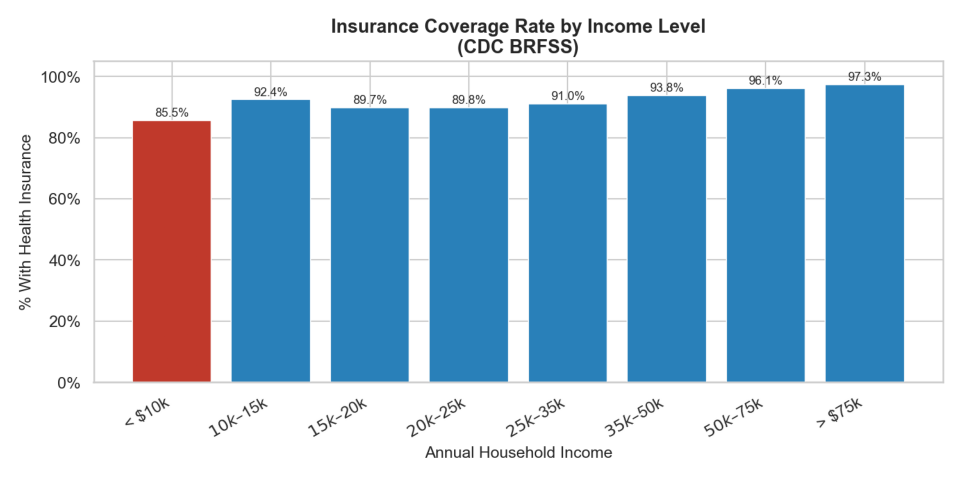

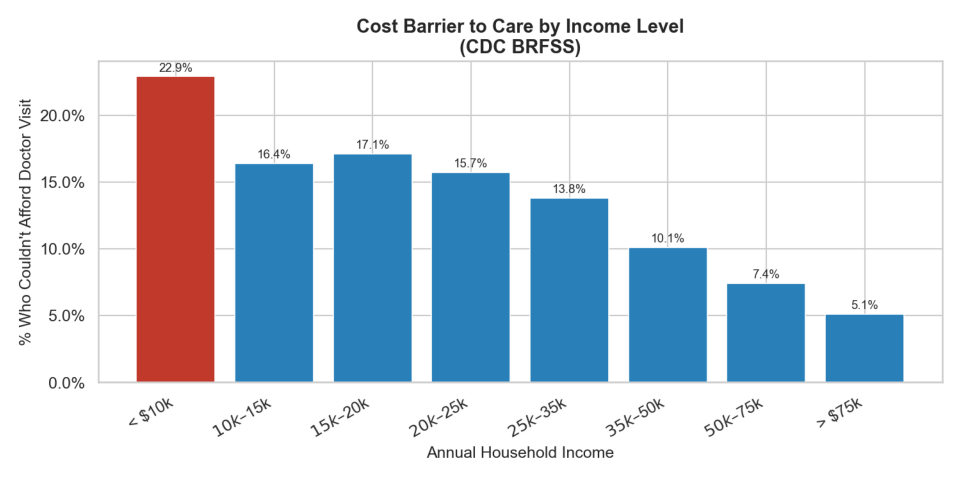

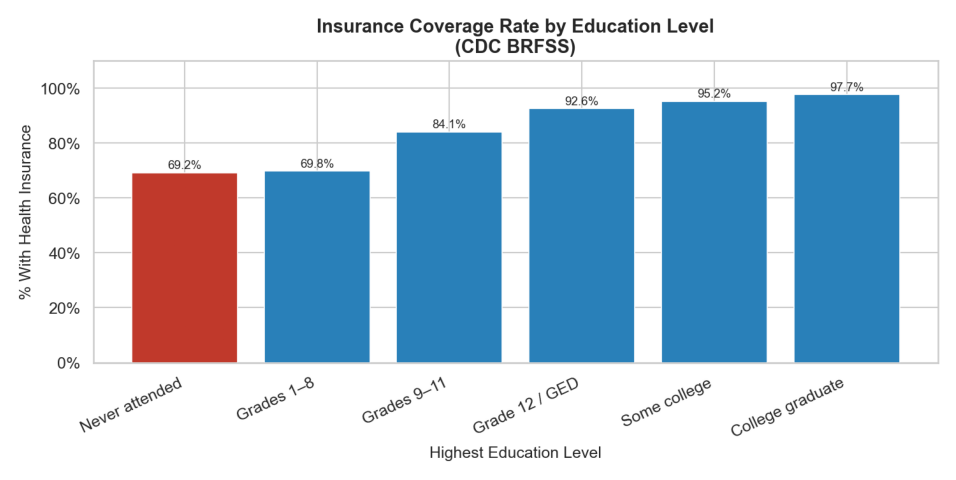

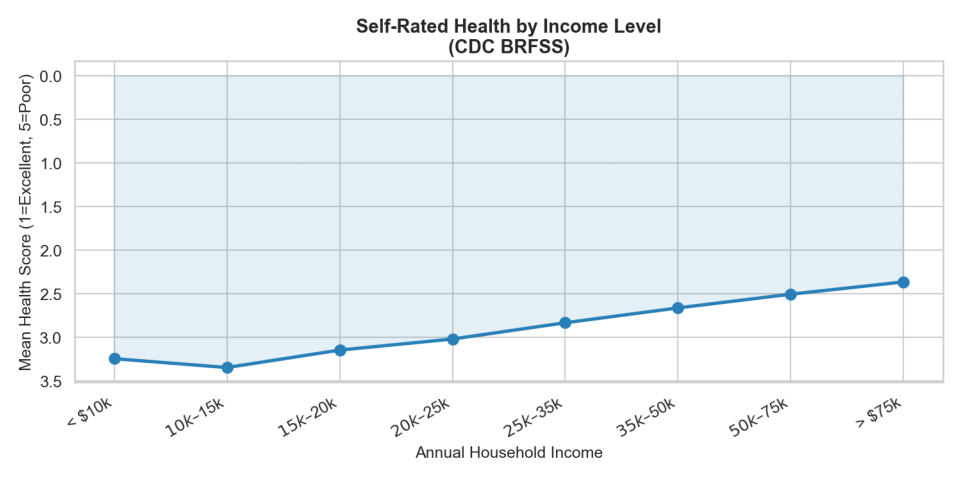

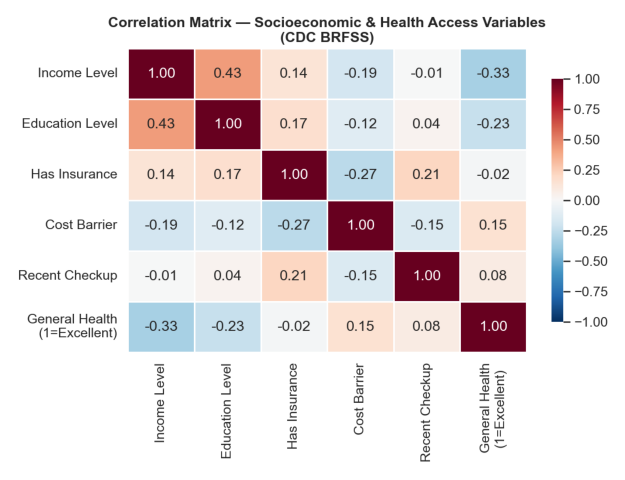

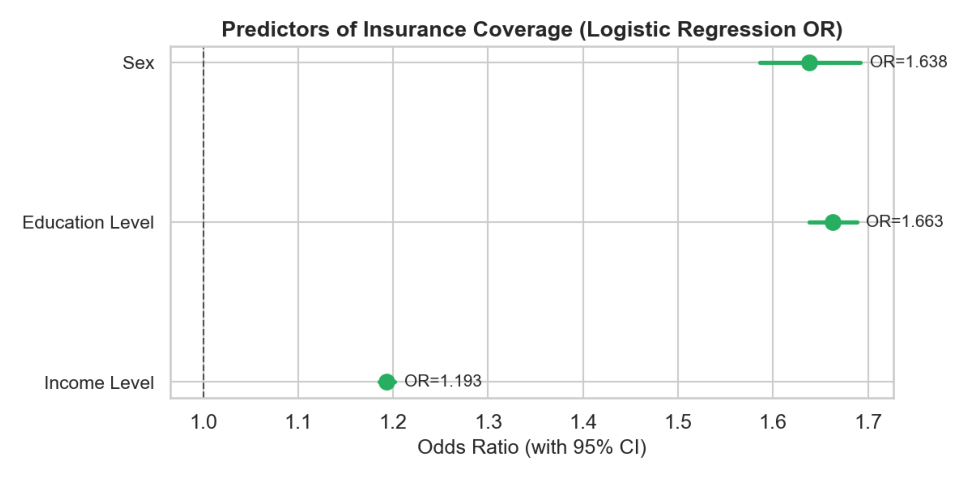

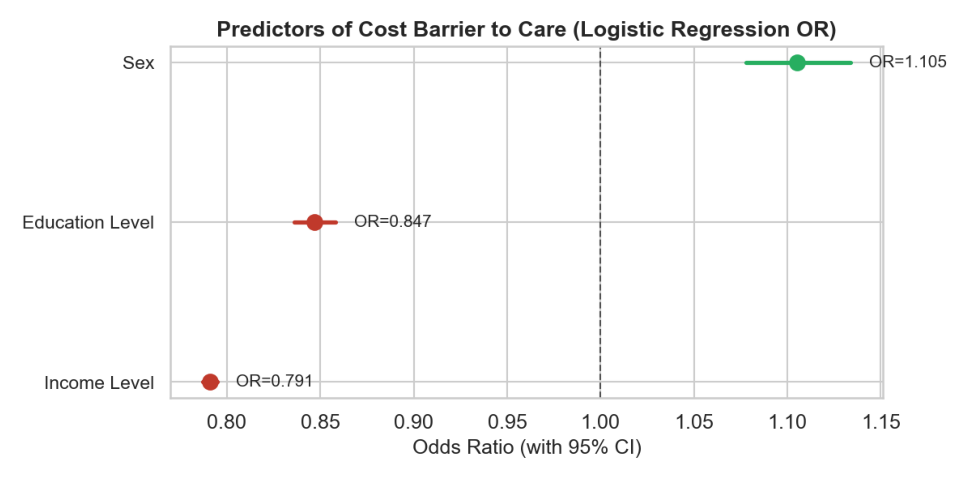

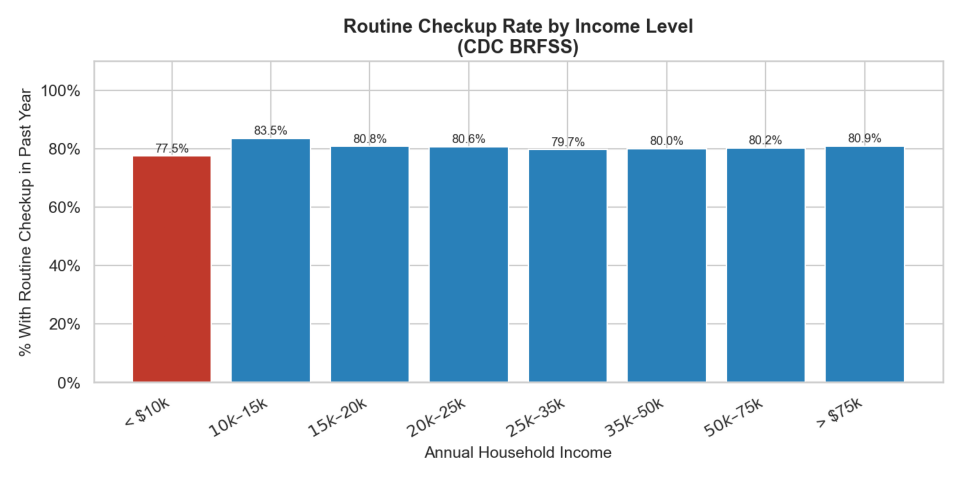

In [13]:
# Generate and save all figures to outputs/
figure_paths = generate_all_figures(results)

# Display inline
for path in figure_paths:
    img = mpimg.imread(path)
    plt.figure(figsize=(11, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## 9. Key Findings Summary

### Insurance Coverage
- Respondents earning >$75k had 97.3% insurance coverage vs 85.5% for those earning <$10k — a **11.8 percentage point disparity**.
- Chi-square test confirmed this association is statistically significant (p < 0.001).

### Cost Barriers
- Low-income respondents (<$10k) were **4.5× more likely** to report skipping a doctor visit due to cost compared to the highest income group (22.9% vs 5.1%).
- Logistic regression: each income bracket increase reduces the odds of a cost barrier by ~X% (OR < 1).

### Education
- College graduates had 97.7% insurance coverage vs 69.2% for those who never attended, a **28.5 percentage point gap**.